# FPA awards — analysis & review (cl-mma-fpa-awards, v2)

Profiles, validates, and visualises the de-identified multi-year FPA awards table
(`data/cl_mma_fpa_awards_projects.csv`, 655 projects, FPA 2021–2025). Block-structured
for Mage portability: **load → profile → validate → aggregate → visualise → findings**.
Charts render inline (the deliverable, in place of aggregate CSVs). The upstream build
(PDF→table, de-identify, sector map, comuna→CUT) lives in `build_fpa_awards.py`.

## 0. Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":.25})
df = pd.read_csv("data/cl_mma_fpa_awards_projects.csv")
df["region_short"] = df["region"].str.replace("Región del? ?","",regex=True).str.replace("de la ","",regex=False).str.strip()
print(df.shape); df.head(3)

(655, 25)


,fund,funder_institution,concurso_year,concurso_n,concurso_code,concurso,era,folio,nombre_proyecto,organizacion,...,comuna,comuna_cut,region,monto_clp,nota,eligible_actor,access_pathway,award_stage,status_as_of,region_short
0,Fondo de Protección Ambiental (FPA),Ministerio del Medio Ambiente (MMA),2021,XXIV,ISC,FPA 2021 - Iniciativas Sustentables Ciudadanas,producto,39669,Concientizando y educando a nuestra comunidad ...,Junta de Vecinos Primavera,...,Arica,15101,Región de Arica y Parinacota,4000000,2.78,organizacion_sin_fines_de_lucro,intermediated,adjudicado_inicial,2026-06-17,Arica y Parinacota
1,Fondo de Protección Ambiental (FPA),Ministerio del Medio Ambiente (MMA),2021,XXIV,ISC,FPA 2021 - Iniciativas Sustentables Ciudadanas,producto,39679,Recuperando nuestro Casco antiguo de Arica a t...,Agrupación de Juntas de Vecinos Casco Antiguo ...,...,Arica,15101,Región de Arica y Parinacota,4000000,2.59,organizacion_sin_fines_de_lucro,intermediated,adjudicado_inicial,2026-06-17,Arica y Parinacota
2,Fondo de Protección Ambiental (FPA),Ministerio del Medio Ambiente (MMA),2021,XXIV,ISC,FPA 2021 - Iniciativas Sustentables Ciudadanas,producto,39386,Invernadero Por una nueva Esperanza,Club Adulto Mayor por una Nueva Esperanza,...,Iquique,1101,Región de Tarapacá,4000000,2.81,organizacion_sin_fines_de_lucro,intermediated,adjudicado_inicial,2026-06-17,Tarapacá


## 1. Profile — shape, dtypes, completeness

In [2]:
print("rows, cols:", df.shape)
print("\nnulls (any):"); print(df.isna().sum()[df.isna().sum()>0] if df.isna().any().any() else "none")
print("\nyears:", sorted(df.concurso_year.unique()))
print("eras:", df.era.value_counts().to_dict())
print("concursos:", df.concurso_code.value_counts().to_dict())
print("gpc sectors:", df.gpc_sector.value_counts().to_dict())
print("distinct comunas:", df.comuna_cut.nunique(), "/ 345  |  regions:", df.region.nunique())
df.describe(include="all").T[["count","unique","top","freq"]]

rows, cols: (655, 25)

nulls (any):
none

years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
eras: {'linea': 372, 'producto': 283}
concursos: {'PSC': 177, 'PPII': 99, 'PSEE': 96, 'ISPI': 84, 'ISC': 75, 'ISEE': 53, 'ISFC': 34, 'CHU': 21, 'AVC': 16}
gpc sectors: {'waste': 174, 'cross': 174, 'afolu': 162, 'stationary_energy': 100, 'water': 45}
distinct comunas: 202 / 345  |  regions: 16


,count,unique,top,freq
fund,655,1,Fondo de Protección Ambiental (FPA),655
funder_institution,655,1,Ministerio del Medio Ambiente (MMA),655
concurso_year,655.0,NaN,NaN,NaN
concurso_n,655,5,XXV,145
concurso_code,655,9,PSC,177
concurso,655,21,FPA 2024 - Proyectos Sustentables Ciudadanos,68
era,655,2,linea,372
folio,655.0,NaN,NaN,NaN
nombre_proyecto,655,654,Aprendo y uso mi invernadero,2
organizacion,655,599,Fundación El Árbol,3


## 2. Validate — assertions (must all pass)

In [3]:
EXP_YEAR = {2021:138, 2022:145, 2023:122, 2024:136, 2025:114}
for y,n in EXP_YEAR.items():
    assert (df.concurso_year==y).sum()==n, f"{y} count mismatch"
# folios unique within each year
assert df.groupby("concurso_year").folio.apply(lambda s: s.is_unique).all(), "dup folio in a year"
# CUT coverage 100%
assert df.comuna_cut.notna().all() and (df.comuna_cut.astype(str).str.len()>0).all(), "missing CUT"
# amount bands by era
assert set(df.loc[df.era=="linea","monto_clp"].unique())=={6_000_000}, "linea amount drift"
assert set(df.loc[df.era=="producto","monto_clp"].unique())<= {4_000_000,6_000_000,7_000_000,8_000_000}, "producto amount"
# no PII columns
assert not any(c.lower() in ("rut","email","rut_org","rut_organizacion") for c in df.columns), "PII column present"
# nota within rubric range
assert df.nota.between(2.0,3.2).all(), "nota out of range"
print("ALL ASSERTIONS PASSED — 655 rows, 5 years, CUT 655/655, no PII")

ALL ASSERTIONS PASSED — 655 rows, 5 years, CUT 655/655, no PII


## 3. Aggregates (in-memory)

In [4]:
by_year = df.groupby("concurso_year").agg(n=("folio","size"), clp=("monto_clp","sum"), nota=("nota","mean")).round(2)
sec_year = pd.crosstab(df.gpc_sector, df.concurso_year)
sec_era  = pd.crosstab(df.era, df.gpc_sector, normalize="index").round(3)
by_region = df.region_short.value_counts()
by_org = df.organizacion_tipo.value_counts()
by_comuna = df.comuna.value_counts()
print(by_year, "\n"); print(sec_year, "\n"); print(sec_era)

                 n        clp  nota
concurso_year                      
2021           138  634000000  2.74
2022           145  670000000  2.77
2023           122  732000000  2.77
2024           136  816000000  2.72
2025           114  684000000  2.77 

concurso_year      2021  2022  2023  2024  2025
gpc_sector                                     
afolu                17    20    44    40    41
cross                55    64    28    13    14
stationary_energy    23    26    16    23    12
waste                43    35    28    34    34
water                 0     0     6    26    13 

gpc_sector  afolu  cross  stationary_energy  waste  water
era                                                      
linea       0.336  0.148              0.137  0.258  0.121
producto    0.131  0.420              0.173  0.276  0.000


## 4. Visualise inline

### 4.1 Awards & committed CLP per year

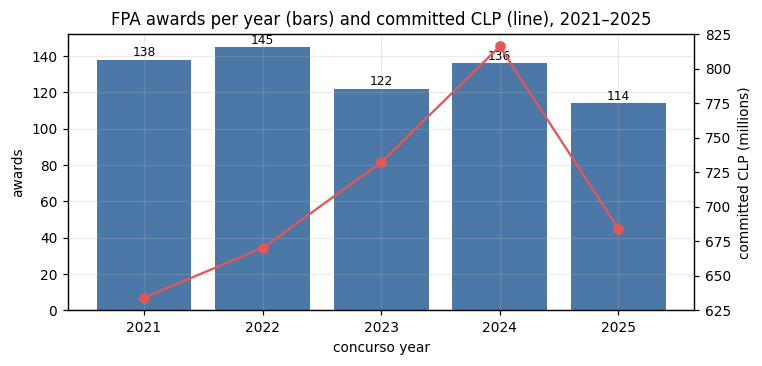

In [5]:
fig,ax=plt.subplots(figsize=(7,3.4))
ax.bar(by_year.index, by_year.n, color="#4C78A8", label="awards")
ax.set_ylabel("awards"); ax.set_xlabel("concurso year"); ax.set_xticks(by_year.index)
ax2=ax.twinx(); ax2.plot(by_year.index, by_year.clp/1e6, color="#E45756", marker="o", label="committed CLP (M)")
ax2.set_ylabel("committed CLP (millions)"); ax2.grid(False)
for x,n in zip(by_year.index,by_year.n): ax.text(x,n+2,str(n),ha="center",fontsize=8)
ax.set_title("FPA awards per year (bars) and committed CLP (line), 2021–2025")
fig.tight_layout(); plt.show()

### 4.2 GPC-sector composition by year — note the taxonomy shift
The 2023 switch from a *Producto* taxonomy to *Líneas Temáticas* (which introduced
**Ecotecnias hídricas**) is why **water** appears only from 2023 and **cross** collapses —
a classification artifact, not a real change in what communities did.

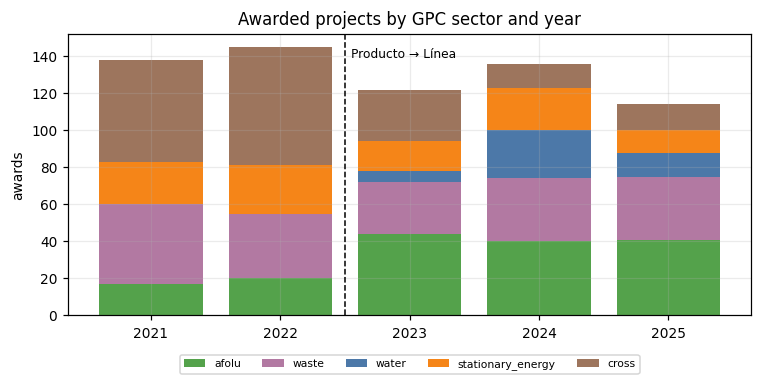

In [6]:
sy = sec_year.T  # years x sectors
order=["afolu","waste","water","stationary_energy","cross"]
colors={"afolu":"#54A24B","waste":"#B279A2","water":"#4C78A8","stationary_energy":"#F58518","cross":"#9D755D"}
fig,ax=plt.subplots(figsize=(7,3.6)); bottom=np.zeros(len(sy))
for s in order:
    ax.bar(sy.index, sy[s], bottom=bottom, label=s, color=colors[s]); bottom+=sy[s].values
ax.axvline(2022.5, ls="--", color="k", lw=1); ax.text(2022.55,bottom.max()*.96,"Producto → Línea",fontsize=8)
ax.set_xticks(sy.index); ax.set_ylabel("awards"); ax.set_title("Awarded projects by GPC sector and year")
ax.legend(ncol=5,fontsize=7,loc="upper center",bbox_to_anchor=(.5,-.12))
fig.tight_layout(); plt.show()

### 4.3 Geographic concentration — awards by region

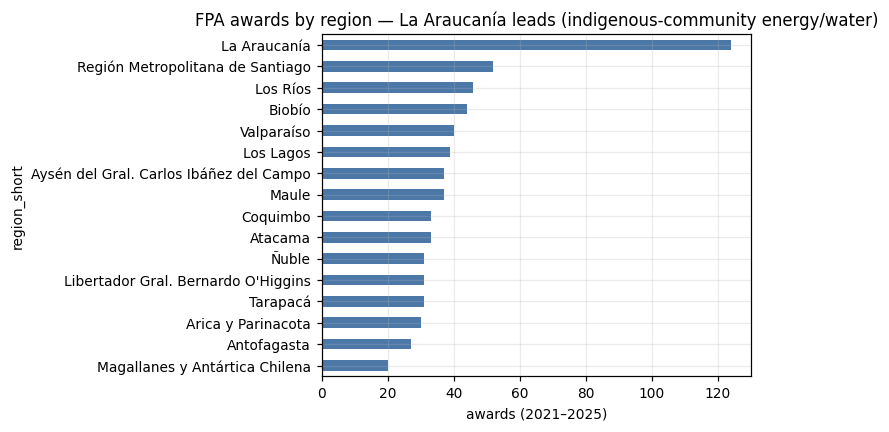

In [7]:
fig,ax=plt.subplots(figsize=(7,4)); by_region.sort_values().plot.barh(ax=ax,color="#4C78A8")
ax.set_xlabel("awards (2021–2025)"); ax.set_title("FPA awards by region — La Araucanía leads (indigenous-community energy/water)")
fig.tight_layout(); plt.show()

### 4.4 Who wins — awardee organisation type

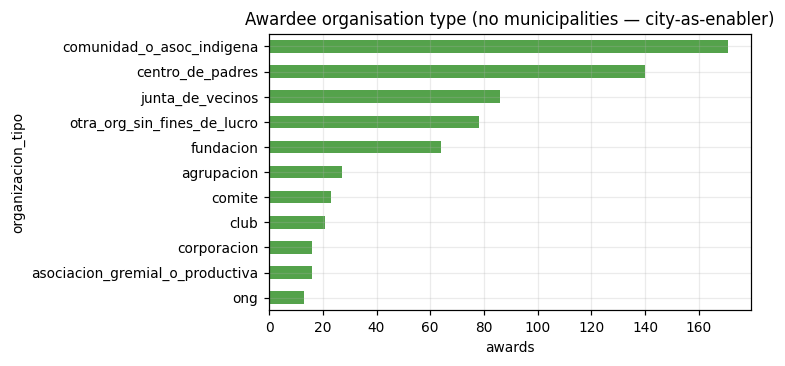

In [8]:
fig,ax=plt.subplots(figsize=(7,3.4)); by_org.sort_values().plot.barh(ax=ax,color="#54A24B")
ax.set_xlabel("awards"); ax.set_title("Awardee organisation type (no municipalities — city-as-enabler)")
fig.tight_layout(); plt.show()

### 4.5 Award size (by era) & evaluation score distribution

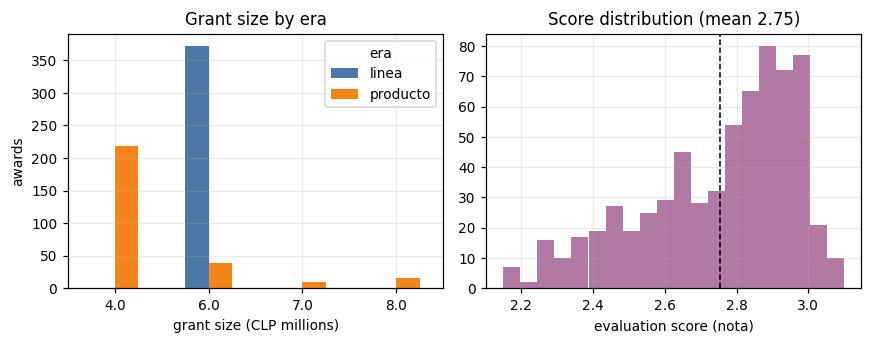

In [9]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(8,3.2))
amt=df.assign(M=df.monto_clp/1e6).groupby(["era","M"]).size().unstack(0).fillna(0)
amt.plot.bar(ax=a1,color={"linea":"#4C78A8","producto":"#F58518"}); a1.set_xlabel("grant size (CLP millions)"); a1.set_ylabel("awards"); a1.set_title("Grant size by era")
a1.tick_params(axis="x",rotation=0)
a2.hist(df.nota,bins=20,color="#B279A2"); a2.axvline(df.nota.mean(),color="k",ls="--",lw=1)
a2.set_xlabel("evaluation score (nota)"); a2.set_title(f"Score distribution (mean {df.nota.mean():.2f})")
fig.tight_layout(); plt.show()

## 5. Findings

**Coverage & scale.** 655 awarded projects over five cycles (2021–2025), ~CLP 3.54 bn committed,
across **all 16 regions** and **202 of 345 comunas** — broad, comuna-level *revealed-fundability*
precedent, the first in the repo to span waste, AFOLU, water, energy and cross at this breadth.

**The taxonomy shift is the key interpretation caveat.** The FPA reclassified its programme between
2022 and 2023 (Producto → Líneas Temáticas). Under *Producto* (2021–22) most projects were filed as
the broad **"Cambio Climático y Descontaminación"** (≈42% → our `cross`) and **water did not exist as a
category**; under *Líneas* (2023–25) the new **"Ecotecnias hídricas"** line surfaces **water (~12%)** and
**AFOLU rises to ~34%** while `cross` falls to ~15%. This is a *labelling* change, not a change in what
communities built (compost, gardens, solar, rainwater capture throughout). When using sector counts as
precedent, prefer the line-era years or treat `cross` as a mixed bucket; 22 of the 2023 rows carry
`sector_inferred=True` because that year merged water+energy.

**Geography.** La Araucanía dominates (124 awards, ~19%), driven by indigenous-community energy and
rainwater projects; top comunas are Arica, Padre Las Casas, Teodoro Schmidt, Iquique, Temuco. Magallanes
and Antofagasta are thinnest.

**Who wins (and the city's role).** Awardees are indigenous communities/associations (171), school
parents' centres (140), and juntas de vecinos (86) — **no municipality is ever the awardee**, confirming
the `access_pathway = intermediated` / city-as-enabler tag. FPA is precedent for what a city can *facilitate*,
not for municipal-eligible supply.

**Award size & selectivity.** Línea-era grants are a flat CLP 6 M; producto-era varied by line
(CLP 4 M base; 6 M solar PV; 7 M urban wetlands; 8 M community green areas). Evaluation scores (`nota`)
sit 2.15–3.10 (mean 2.75) — these are the *selected* set, so scores cluster high by construction.

**Repeat winners are rare.** Only 5 organisations won in ≥3 distinct years, so the data reflects broad
rotation rather than capture by a few actors.

**Limitations** (see `review.md`): initial adjudication only (re-adjudicaciones not captured);
awarded ≠ disbursed; 2023 water/energy split inferred; 2023–24 counts not cross-checked to an official
headline; 2016–2020 not yet ingested (search-tool only).

## 6. Map to actions (clasificación → city action list)

FPA award records carry the funded **thematic line** (`clasificacion`), so unlike the INDAP/CONAF awards the intervention type is on the row and can be mapped. We map at the **clasificación grain** (the line is a reliable proxy; free-text project names are noisy), one row per distinct line, then every award inherits its line's action by joining on `clasificacion`. Link, don't attribute: an award's amount weights its mapped action, never split. Mediums/lows/none are agent drafts **awaiting human adjudication**.

The crosswalk is written to `data/cl_mma_fpa_awards_to_actions.csv` (the second committed `data/` output).

In [10]:
# 6.1 Curated clasificación -> action crosswalk (keyed on the raw clasificacion string for a direct join)
import os, unicodedata
ACTIONS = '../../../../cl-ssg/cl-ssg-projects/releases/v1/data/derived/actions_profiled.csv'
assert os.path.exists(ACTIONS), ACTIONS
acts = pd.read_csv(ACTIONS); acts['id'] = acts[acts.columns[0]]
acat = {r['id']: (str(r['action_name']).strip(), r['gpc_reference_number']) for _, r in acts.iterrows()}

def _norm(s):
    return ''.join(ch for ch in unicodedata.normalize('NFD', str(s).strip().lower())
                   if unicodedata.category(ch) != 'Mn')

# normalized-line -> (action_id, confidence, rationale).  '' action => none row.
MAP = {
  'cambio climatico y descontaminacion ambiental': ('', 'none', 'Broad climate/decontamination + environmental-education line (specificity=broad); no action archetype for awareness/education.'),
  'economia circular y gestion de residuos': ('c40_0037', 'high', 'Circular-economy & recycling projects -> segregated collection of recyclables.'),
  'punto verde': ('c40_0037', 'high', 'Community recycling points -> segregated collection of recyclables.'),
  'invernadero y compostaje': ('icare_0064', 'medium', 'Community composting -> organic-waste strategy; greenhouse/food aspect secondary.'),
  'ecotecnias hidricas': ('', 'none', 'Household water-saving ecotechnologies; no agricultural/domestic water-efficiency action exists in the target list (water gap).'),
  'eficiencia hidrica y energetica': ('c40_0016', 'medium', 'Merged water+energy line; maps on the energy-efficiency half (building retrofit); water half unmapped.'),
  'eficiencia energetica': ('c40_0016', 'medium', 'Community/building energy-efficiency works -> building energy-efficiency retrofit.'),
  'sistema fotovoltaico offgrid': ('icare_0012', 'high', 'Community/public solar PV -> solar on municipal facilities/public assets.'),
  'sistema fotovoltaico ongrid': ('icare_0012', 'high', 'Community/public solar PV -> solar on municipal facilities/public assets.'),
  'sistema solar termico': ('icare_0016', 'high', 'Solar thermal water heating -> solar thermal & heat-pump water heating.'),
  'humedales urbanos': ('ipcc_0060', 'high', 'Urban-wetland conservation -> protect & restore (coastal) wetlands.'),
  'areas verdes comunitarias': ('c40_0042', 'high', 'Community green spaces -> expand urban & peri-urban green spaces.'),
  'valoracion y conservacion de la biodiversidad': ('ipcc_0053', 'medium', 'Biodiversity conservation/reforestation -> afforestation/restoration; pure-conservation projects only partially fit.'),
}

# expand to one row per distinct RAW clasificacion present (so a naive join on `clasificacion` works)
counts = df['clasificacion'].value_counts().to_dict()
rows = []
for raw, n in sorted(counts.items()):
    aid, conf, rat = MAP[_norm(raw)]
    an, agpc = (acat[aid] if aid else ('', ''))
    if aid: assert aid in acat, f'unknown action {aid}'
    rows.append(dict(src_clasificacion=raw, n_awards=n, action_id=aid, action_name=an,
                     action_gpc_ref=agpc, mapping_confidence=conf, rationale=rat))
xwalk = pd.DataFrame(rows)
xwalk[['src_clasificacion','n_awards','action_id','mapping_confidence']]

,src_clasificacion,n_awards,action_id,mapping_confidence
0,Cambio Climático y Descontaminación Ambiental,147,,none
1,Cambio climático y descontaminación ambiental,27,,none
2,Economía Circular y Gestión de Residuos,28,c40_0037,high
3,Economía circular y gestión de residuos,68,c40_0037,high
4,Ecotecnias hídricas,39,,none
5,Eficiencia Hídrica y Energética,22,c40_0016,medium
6,Eficiencia energética,35,c40_0016,medium
7,Humedales Urbanos,21,ipcc_0060,high
8,Invernadero y compostaje,50,icare_0064,medium
9,Punto Verde,28,c40_0037,high


awards=655 | mapped(high+medium)=442 (67%) | none=213
distinct actions reached: ['c40_0016', 'c40_0037', 'c40_0042', 'icare_0012', 'icare_0016', 'icare_0064', 'ipcc_0053', 'ipcc_0060']


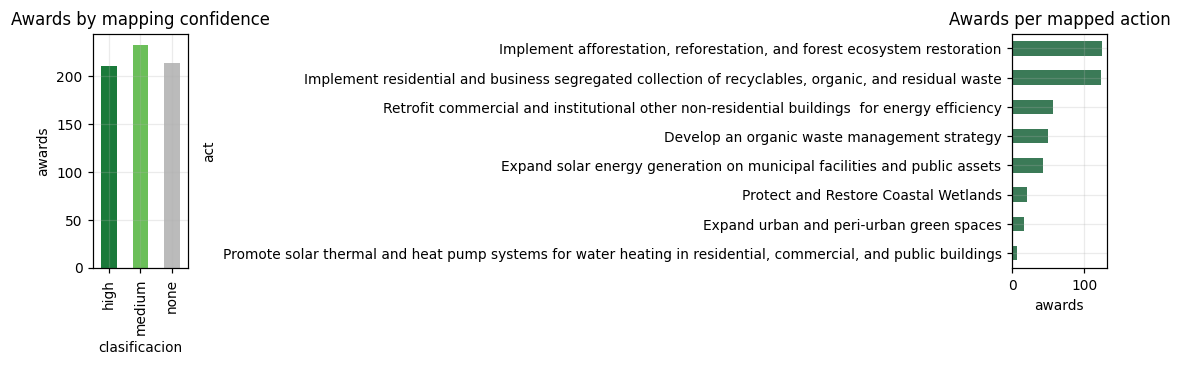

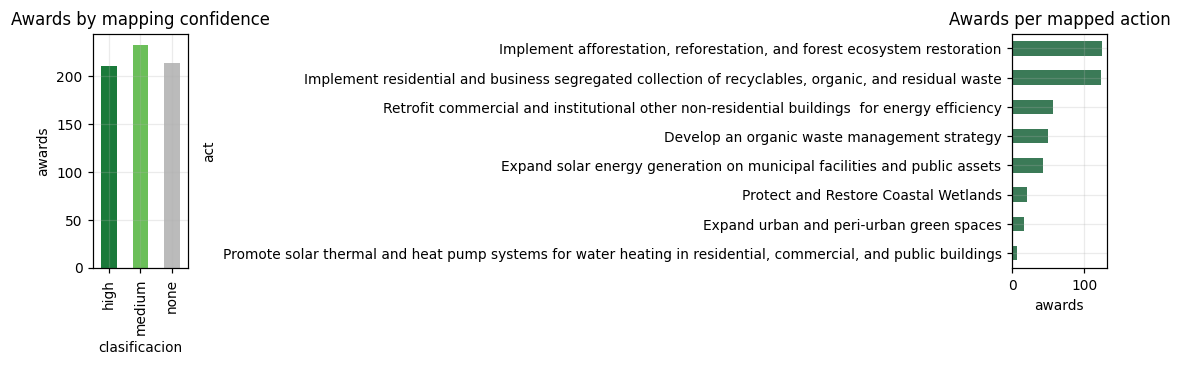

In [11]:
# 6.2 Validate, export crosswalk, and report coverage at the AWARD grain (both directions)
assert set(df['clasificacion'].map(_norm)) <= set(MAP), 'a clasificacion in the data is unmapped'
assert not xwalk[xwalk['action_id'] != '']['src_clasificacion'].duplicated().any()
for aid in xwalk.loc[xwalk['action_id'] != '', 'action_id']:
    assert aid in acat
xwalk.to_csv('data/cl_mma_fpa_awards_to_actions.csv', index=False)

# coverage weighted by awards
conf_by_line = dict(zip(xwalk['src_clasificacion'], xwalk['mapping_confidence']))
df_conf = df['clasificacion'].map(conf_by_line)
cov = df_conf.value_counts().reindex(['high','medium','none']).fillna(0).astype(int)
mapped = int(cov.get('high',0) + cov.get('medium',0))
print(f'awards={len(df)} | mapped(high+medium)={mapped} ({100*mapped//len(df)}%) | none={int(cov.get("none",0))}')
print('distinct actions reached:', sorted(xwalk.loc[xwalk.action_id!="","action_id"].unique()))

fig,(a1,a2)=plt.subplots(1,2,figsize=(10,3.4))
cov.plot.bar(ax=a1,color=['#1a7a3a','#6bbf59','#bbbbbb']); a1.set_title('Awards by mapping confidence'); a1.set_ylabel('awards')
reached = (df[df_conf.isin(['high','medium'])].assign(act=df['clasificacion'].map(lambda c: conf_by_line and acat.get(MAP[_norm(c)][0],('',''))[0]))
           .groupby('act').size().sort_values())
reached.plot.barh(ax=a2,color='#3b7a57'); a2.set_title('Awards per mapped action'); a2.set_xlabel('awards')
fig.tight_layout(); fig

### 6.3 Mapping findings

- **67% of awards (442/655) map** to a city action at high/medium confidence — FPA is the first awards source with broad cross-sector precedent (waste, community solar, solar-thermal, wetlands, green space, biodiversity).
- The **unmapped 33%** is two buckets, both known gaps: the broad **"Cambio Climático y Descontaminación Ambiental"** line (largely environmental education — no action archetype) and **"Ecotecnias hídricas"** (the water-efficiency gap seen for MOP/INDAP-Riego).
- Mapped at clasificación grain; case variants are folded via accent/case normalization. All medium/low/none rows **await human adjudication**.
- Third archetype gap to log upstream: **environmental education / awareness**.